# EasyOCR experiments - defining functions and exploring outputs

## Load packages and check working directory

In [9]:
import easyocr
import cv2
from matplotlib import pyplot as plt
import re
import os

current_dir = os.path.abspath('.')
parent_dir = os.path.dirname(current_dir)
print(f"Current directory: {current_dir}")
print(f"Parent directory: {parent_dir}")

Current directory: c:\Users\SamHenderson-Palmer\Documents\Github\00.Personal\ocr-ingredients-checker\notebooks
Parent directory: c:\Users\SamHenderson-Palmer\Documents\Github\00.Personal\ocr-ingredients-checker


## Set fixed paths and variables

In [10]:
MODEL_PATH = f'{parent_dir}/models/easyocr'
IMAGE_PATH = f'{parent_dir}/assets/sample_images/qv_gentlewash.jpg'
ALLERGEN_LIST = ['Coconut oil', 'Beeswax', 'Tocopherol', "Paraben"]
DELIMITERS = {",", ";", ":"}

## Read in image

In [11]:
img = cv2.imread(IMAGE_PATH)

## Load local ocr model files

In [12]:
reader = easyocr.Reader(['en'], model_storage_directory = MODEL_PATH, gpu = False)

Using CPU. Note: This module is much faster with a GPU.


## Store OCR text and corresponding bounding box info

width_ths = 0 just ensures we get the smallest possible fragments of text (usually words) so that we can get coordinates for each to draw a bounding box around it. This gets around the trouble of line breaks in ingredients lists:

"propolis, sodium  <br> 
chloride, parabens"

So now we get "propolis,", "sodium", "chloride," and "parabens" instead of a larger width_ths which might give us "propolis, sodium" and "chloride, parabens". The bounding box around the latter is less granular and would not be relating to the same ingredient separated by commas!

In [13]:
result = reader.readtext(IMAGE_PATH, width_ths=0, adjust_contrast=0.5)
result

c:\Users\SamHenderson-Palmer\Documents\Github\00.Personal\ocr-ingredients-checker\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[([[np.int32(89), np.int32(26)],
   [np.int32(209), np.int32(26)],
   [np.int32(209), np.int32(52)],
   [np.int32(89), np.int32(52)]],
  'INGREDIENTS:',
  np.float64(0.738173337289462)),
 ([[np.int32(208), np.int32(26)],
   [np.int32(252), np.int32(26)],
   [np.int32(252), np.int32(54)],
   [np.int32(208), np.int32(54)]],
  'Aqua',
  np.float64(0.9988031387329102)),
 ([[np.int32(250), np.int32(26)],
   [np.int32(312), np.int32(26)],
   [np.int32(312), np.int32(52)],
   [np.int32(250), np.int32(52)]],
  '(Water);',
  np.float64(0.6720134819130821)),
 ([[np.int32(312), np.int32(26)],
   [np.int32(398), np.int32(26)],
   [np.int32(398), np.int32(52)],
   [np.int32(312), np.int32(52)]],
  'Carthamus',
  np.float64(0.9970891740793209)),
 ([[np.int32(394), np.int32(28)],
   [np.int32(470), np.int32(28)],
   [np.int32(470), np.int32(54)],
   [np.int32(394), np.int32(54)]],
  'Tinctorius',
  np.float64(0.7406470055149884)),
 ([[np.int32(90), np.int32(54)],
   [np.int32(176), np.int32(54)],
   

### Create normalising function to lowercase and strip OCR text of delimiters and redundant whitespace

In [29]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r'[^\w\s-]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

normalize_text("INGREDIENTS:   ")

'ingredients'

## Isolate OCR info needed for checking ingredient matches (cleaned text) and drawing bounding box (top left and bottom right x and y coordinates)

In [30]:
def ocr_to_word_records(ocr_result):
    word_records = []

    for bbox, text, confidence in ocr_result:

        # x and y coordinates of top_left rectangle
        top_left = tuple((int(val) for val in bbox[0]))
        # x and y coordinates of bottom right rectangle
        bottom_right = tuple((int(val) for val in bbox[2]))

        word_records.append({
            "raw_text": text,
            "clean_text": normalize_text(text),
            "top_left": top_left,
            "bottom_right": bottom_right,
        })

    return word_records

word_records = ocr_to_word_records(result)
word_records[0]

{'raw_text': 'INGREDIENTS:',
 'clean_text': 'ingredients',
 'top_left': (89, 26),
 'bottom_right': (209, 52)}

## Create functions to detect if there is a delimiter (usually a comma or semicolon) at the end of each word/token. This usually indicates the end of an ingredient in an ingredients list

In [31]:
def ends_with_delimiter(text):
    text = text.strip()
    return len(text) > 0 and text[-1] in DELIMITERS

ends_with_delimiter("aloe vera, ")

True

## Because of more granularity in our OCR width_ths parameter we might also end up with JUST delimiter so need to consider the ingredients before that too

In [35]:
def is_delimiter_only(text):
    return text.strip() in DELIMITERS

print(is_delimiter_only("paraben"))
print(is_delimiter_only(";"))

False
True


## Now for the more complex stuff - aggregating individual words and their coordinates into actual combined ingredients (by separating by delimiter)

In [37]:
def word_records_to_ingredient_records(word_records):
    ingredients = []
      
    current_ingredient = []
    current_ingredient_text = []
    
    for token in word_records:
        raw_text = token["raw_text"] # For spotting boundaries between ingredients
        clean_text = token["clean_text"] # For matching to allergen list
        
        # This prevents tokens being appended if they're just ";"
        if clean_text:
            # Creating list of current ingredients before appending
            current_ingredient_text.append(clean_text)

            # For drawing bounding box of each ingredient token
            current_ingredient.append({
            "raw_text": raw_text,
            "top_left": token["top_left"],
            "bottom_right": token["bottom_right"]
            })

        # Once we get to a token that ends with a delimiter or is a solo delimiter we append and restart
        if ends_with_delimiter(raw_text) or is_delimiter_only(raw_text):
                full_current_ingredient_text = " ".join(current_ingredient_text).strip()
                ingredients.append({
                    "ingredient_text": full_current_ingredient_text,
                    "words": current_ingredient.copy()
                })
                current_ingredient = []
                current_ingredient_text = [] 
    # Fallback in case there is no delimiter at the end of the ingredients list
    if current_ingredient:
            full_current_ingredient_text = " ".join(current_ingredient_text).strip()
            ingredients.append({
                "ingredient_text": full_current_ingredient_text,
                "words": current_ingredient.copy()
            })
            current_ingredient = []
            current_ingredient_text = [] 
            
    return ingredients

### We can see an example of what this output now looks like where we have a two or more word ingredient

In [46]:
ingredients = word_records_to_ingredient_records(word_records)
ingredients[5]

{'ingredient_text': 'sodium laureth sulfate',
 'words': [{'raw_text': 'Sodium',
   'top_left': (392, 56),
   'bottom_right': (452, 82)},
  {'raw_text': 'Laureth', 'top_left': (92, 82), 'bottom_right': (156, 108)},
  {'raw_text': 'Sulfate,', 'top_left': (152, 82), 'bottom_right': (210, 108)}]}

## We specified our allergen list in the setup as a fixed variable - now we can normalise that list as a prereq to finding a match in ingredients text

In [49]:
def normalize_allergen_list(allergen_list):
    return {normalize_text(allergen) for allergen in allergen_list}

normalised_allergens = normalize_allergen_list(ALLERGEN_LIST)
normalised_allergens

{'beeswax', 'coconut oil', 'paraben', 'tocopherol'}

## We now want to flag up any ingredients in our OCR list that match any of our allergens

In [55]:
def flag_matching_ingredients(ingredient_records, normalized_allergens):
    for ingredient in ingredient_records: 
        # Create a variable that answers 'Does any user defined allergen match this ingredient?'
        ingredient["is_match"] = any(
            allergen in ingredient["ingredient_text"] 
            for allergen in normalized_allergens
        )
    return ingredient_records

ingredients_match = flag_matching_ingredients(ingredients, normalised_allergens)
ingredients_match[10]

{'ingredient_text': 'propylparaben',
 'words': [{'raw_text': 'Propylparaben,',
   'top_left': (234, 134),
   'bottom_right': (344, 162)}],
 'is_match': True}

## We now have each ingredient that appears between a delimiter, the words within it and their corresponding x and y coordinates for top left and bottom right to draw around them. Purpose of this is to plot over the image the user takes to highlight where on the ingredients the match occurs.

In [59]:
def draw_matched_ingredients(img, ingredient_records):
    output_img = img.copy()

    for ingredient in ingredient_records:
        if ingredient["is_match"]:
            for word in ingredient["words"]:
                cv2.rectangle(output_img, word["top_left"], word["bottom_right"], (0, 255, 0), 2)
    return output_img

In [62]:
output_img = draw_matched_ingredients(img, ingredients_match)
output_img

array([[[185, 188, 186],
        [183, 186, 184],
        [181, 184, 182],
        ...,
        [177, 190, 192],
        [174, 187, 189],
        [172, 185, 187]],

       [[182, 185, 183],
        [181, 184, 182],
        [180, 183, 181],
        ...,
        [175, 188, 190],
        [173, 186, 188],
        [171, 184, 186]],

       [[180, 183, 181],
        [180, 183, 181],
        [179, 182, 180],
        ...,
        [172, 185, 187],
        [172, 185, 187],
        [171, 184, 186]],

       ...,

       [[134, 137, 135],
        [134, 137, 135],
        [134, 137, 135],
        ...,
        [152, 173, 181],
        [149, 170, 178],
        [148, 169, 177]],

       [[132, 135, 133],
        [132, 135, 133],
        [132, 135, 133],
        ...,
        [152, 173, 181],
        [149, 170, 178],
        [147, 168, 176]],

       [[131, 134, 132],
        [132, 135, 133],
        [132, 135, 133],
        ...,
        [152, 173, 181],
        [149, 170, 178],
        [147, 168, 176]]

## Finally we can plot it!

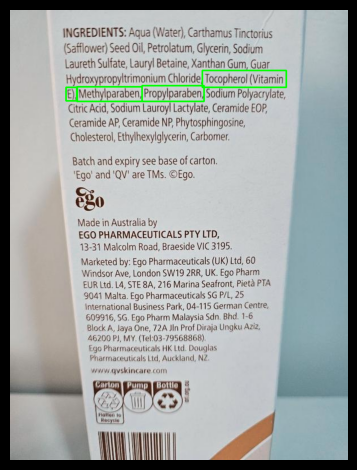

In [61]:
plt.imshow(output_img)
plt.axis("off")
plt.tight_layout()
plt.show()